# 🎮 Cubee — Analyse de l'entraînement Q-Learning

> **Projet IA — HENaLLux (IN252)**
> Auteurs : Victor Van Zieghem & Ethan Nickels
> Source : [VVZ-Data/Projet_IA](https://github.com/VVZ-Data/Projet_IA)

---

Ce notebook importe **directement le code source du projet** et analyse 6 agents Q-Learning
comparés par paires d'hyperparamètres.

## 🎯 Protocole — 3 paires, un paramètre isolé par paire

| Paire | Agent | α | ε₀ | γ | Paramètre isolé |
|-------|-------|---|------|---|------------------|
| **A** | IA-1 | 0.1 | **0.5** | 0.9 | ε₀ |
|       | IA-2 | 0.1 | **0.9** | 0.9 | ← défaut projet |
| **B** | IA-3 | **0.05** | 0.7 | 0.9 | α |
|       | IA-4 | **0.3** | 0.7 | 0.9 | |
| **C** | IA-5 | 0.1 | 0.7 | **0.70** | γ |
|       | IA-6 | 0.1 | 0.7 | **0.99** | |

## 📋 Sommaire
1. [Présentation du jeu](#1)
2. [Import & setup](#2)
3. [Entraînement des 6 agents](#3)
4. [Paire A — Impact de ε₀](#4)
5. [Paire B — Impact de α](#5)
6. [Paire C — Impact de γ](#6)
7. [Vue d'ensemble](#7)
8. [Conclusions par paire](#8)
9. [Sélection des paramètres — IA-7](#9)
10. [Entraînement IA-7 — Agent de production (250 000 parties)](#10)

## 1. 🎮 Présentation du jeu <a id='1'></a>

### Règles de Cubee
Deux joueurs se déplacent sur une grille **5×5**. Chaque case visitée est capturée.  
Le joueur avec le plus de cases en fin de partie gagne.

### ⚡ Mécanique centrale : `check_enclosure` (BFS — `game_model.py`)
Après chaque déplacement, un **BFS** part de la position de l'adversaire.  
Les cases vides **non atteignables** par l'adversaire sont automatiquement capturées.

```
Avant :   Après check_enclosure :
1 1 1 1   1 1 1 1
1 0 0 1   1 1 1 1   ← 0 encerclés → capturés par J1
1 0 1 1   1 1 1 1
1 1 2 2   1 1 2 2
```

### Fonctionnement de l'IA (`player.py`)

| Élément | Détail |
|---------|--------|
| Encodage état | `"{turn}_{pos2}_{pos1}_{s1}_{s2}_{board_flat}"` — plateau entier aplati |
| Récompense immédiate | `my_gain - 0.5 × opponent_gain` (cases capturées dont enclos) |
| Récompense terminale | **+10** victoire / **-10** défaite |
| Exploration (ε-greedy) | `random.choice(ALL moves)` — y compris mouvements invalides |
| Exploitation | `max Q(s,a)` sur `legal_move()` uniquement |
| Décroissance ε | multiplicative **× 0.95** jusqu'à min 0.05 |

### ⚠️ Note sur le Win Rate attendu
L'espace d'états est `3^25 ≈ 847 milliards` de combinaisons possibles.  
En 300 000 parties, chaque état est visité en moyenne **< 1 fois**.  
→ La Q-table ne converge pas en une seule session : **c'est voulu** — le projet persiste  
la Q-table dans `cubee.db` (SQLite) pour accumulation sur plusieurs sessions.  
→ Dans ce notebook, on mesure la **progression relative** entre agents, pas la performance absolue.


## 2. 📦 Import & Setup <a id='2'></a>

Nous installons les dépendances requises et importons le code source réel du jeu.
La classe `RamQTable` remplace la base de données SQLite pour éviter de polluer
`cubee.db` en production et pour accélérer significativement l’entraînement.

> ⚠️ Le notebook doit être exécuté depuis la **racine du projet** pour que `games/cubee/` soit accessible.


In [3]:
# ── Dépendance installation ────────────────────────────────────
!pip install numpy matplotlib pandas seaborn tqdm --quiet



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### Imports et configuration


In [4]:
# ── Imports ────────────────────────────────────────────────
import random
import time
import warnings
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

# ── Import direct du code source du projet ──────────────────
from games.cubee.player import Player, AI
from games.cubee.ai_train import train_with_progress, _NB_STEPS

print('✅ Imports OK — code source réel chargé')
print(f'   _NB_STEPS  : {_NB_STEPS:.2f}  →  nb_epsilon = {int(300_000 / _NB_STEPS)} pour 300 000 parties')
print(f'   Espace d’états théorique : 3^25 = {3**25:,}')
print(f'   Couverture à 300k parties : ~{300_000 * 25 / (3**25) * 100:.6f}% de tous les états')


✅ Imports OK — code source réel chargé
   _NB_STEPS  : 56.35  →  nb_epsilon = 5323 pour 300 000 parties
   Espace d’états théorique : 3^25 = 847,288,609,443
   Couverture à 300k parties : ~0.000885% de tous les états


### Q-Table en mémoire (`RamQTable`)

Pour éviter d’écrire dans `cubee.db` pendant l’analyse, on utilise une Q-table en RAM
avec la même interface que `QTableRepo`. Cela rend l’entraînement ~10× plus rapide dans le notebook.


In [5]:
# ── Q-Table en RAM ───────────────────────────────────────────
# Remplace SQLAlchemy/cubee.db pour le notebook — interface identique à QTableRepo

class RamQTable:
    """Q-Table en mémoire vive. Interface identique à QTableRepo."""
    def __init__(self):
        self._table = defaultdict(float)

    def get_q_value(self, gama, lr, state, action):
        return self._table[(str(gama), str(lr), state, action)]

    def update_q_value(self, gama, lr, state, action, value):
        self._table[(str(gama), str(lr), state, action)] = value

    def init_final_states(self, gama, lr): pass
    def commit(self): pass

    @property
    def size(self):
        return len(self._table)


# ── Seeds reproductibles ───────────────────────────────────────
SEEDS = {
    'IA-1': 42, 'IA-2': 42, 'IA-3': 42,
    'IA-4': 42, 'IA-5': 42, 'IA-6': 42, 'IA-7': 42,
}

# ── Palette visuelle ─────────────────────────────────────────
COLORS = {
    'IA-1': '#1a7a3c',  # vert foncé   (Paire A, ε₀=0.5)
    'IA-2': '#55c46e',  # vert vif     (Paire A, ε₀=0.9 — défaut)
    'IA-3': '#1a4fa0',  # bleu foncé   (Paire B, α=0.05)
    'IA-4': '#4da3e8',  # bleu vif     (Paire B, α=0.3)
    'IA-5': '#b94a00',  # orange foncé (Paire C, γ=0.70)
    'IA-6': '#f5a623',  # orange vif   (Paire C, γ=0.99)
    'IA-7': '#e74c3c',  # rouge        (agent optimal)
}
STYLES = {
    'IA-1': '-', 'IA-2': '--', 'IA-3': '-', 'IA-4': '--',
    'IA-5': '-', 'IA-6': '--', 'IA-7': '-',
}

print('✅ RamQTable & seeds reproductibles prêts')


✅ RamQTable & seeds reproductibles prêts


## 3. 🏋️ Entraînement des 6 agents de référence (IA-1 à IA-6) <a id='3'></a>

Chaque agent joue **300 000 parties** contre un adversaire aléatoire.
Les agents s'entraînent **séquentiellement** (l'un après l'autre).

> ℹ️ **IA-7 (agent de production) n'est pas entraîné ici.** Son entraînement est déclenché
> en Section 10, après sélection des paramètres optimaux en Section 9.

Une barre `tqdm` suit la progression :
- Quel agent est en cours d'entraînement
- Combien de parties ont été jouées pour l'agent en cours

> ⚠️ **Durée estimée** : environ 25 à 45 minutes selon votre machine.
> La fenêtre de calcul est fixée à 2 500 parties (1 % du total) pour des courbes lisses.

In [6]:
# ── Configuration des 6 agents de référence ────────────────────────────
# Chaque ligne : (nom, alpha, gamma, epsilon_initial)
# IA-7 est entraîné séparément en Section 10, après sélection des paramètres

CONFIGS = [
    ('IA-1', 0.1,  0.9,  0.5),    # Paire A — ε₀ faible
    ('IA-2', 0.1,  0.9,  0.9),    # Paire A — ε₀ élevé (défaut projet)
    ('IA-3', 0.05, 0.9,  0.7),    # Paire B — α faible
    ('IA-4', 0.3,  0.9,  0.7),    # Paire B — α élevé
    ('IA-5', 0.1,  0.70, 0.7),    # Paire C — γ faible
    ('IA-6', 0.1,  0.99, 0.7),    # Paire C — γ élevé
]

N_EPISODES = 300000   # nombre de parties par agent
WINDOW     = 3000     # fenêtre de calcul du win rate

PAIR_NAMES = ['IA-1', 'IA-2', 'IA-3', 'IA-4', 'IA-5', 'IA-6']  # agents de référence

print(f'Agents Section 3   : {len(CONFIGS)}  (IA-1 à IA-6)')
print(f'Parties par agent  : {N_EPISODES:,}')
print(f'Fenêtre win rate   : {WINDOW:,}')
print(f'Total parties      : {N_EPISODES * len(CONFIGS):,}')
print()
print('  ℹ️  IA-7 sera entraîné séparément en Section 10.')

Agents Section 3   : 6  (IA-1 à IA-6)
Parties par agent  : 300,000
Fenêtre win rate   : 3,000
Total parties      : 1,800,000

  ℹ️  IA-7 sera entraîné séparément en Section 10.


### Boucle d’entraînement

La fonction `train_and_log()` encapsule `train_with_progress()` du code source du jeu.
Elle enregistre — tous les `WINDOW` parties :
- `win_rate`  : pourcentage de victoires sur la fenêtre
- `q_size`    : nombre d’entrées Q(s,a) explorées
- `epsilon`   : valeur courante du taux d’exploration


In [7]:
# ── Fonction d'entraînement avec logs ──────────────────────────────────
def train_and_log(name: str, alpha: float, gamma: float, epsilon: float,
                  n_ep: int = N_EPISODES, window: int = WINDOW,
                  seed: int = 42, outer_bar=None) -> tuple:
    """
    Entraîne un agent Q-Learning et retourne l'agent + un DataFrame de logs.

    Colonnes du DataFrame :
      - ep         : numéro de la partie (multiple de `window`)
      - win_rate   : taux de victoire sur la fenêtre
      - wins_window: nombre de victoires dans la fenêtre
      - q_size     : nombre d'entrées Q(s,a) en RAM
      - epsilon    : valeur courante d'epsilon
    """
    random.seed(seed)
    np.random.seed(seed)

    # Création de l'agent et de son adversaire
    student  = AI(name, gama=gamma, learning_rate=alpha, epsilon=epsilon)
    student.q_table = RamQTable()
    student.init_db()
    opponent = Player('Random')

    log = defaultdict(list)
    prev_wins = prev_losses = prev_draws = 0

    # Barre de progression interne à l'agent (tqdm imbriquée)
    inner_bar = tqdm(
        total=n_ep,
        desc=f'  {name} (α={alpha}, γ={gamma}, ε₀={epsilon})',
        leave=False,
        unit='games',
    )

    def progress(current: int, total: int) -> None:
        nonlocal prev_wins, prev_losses, prev_draws

        # Mise à jour de la barre interne
        inner_bar.update(current - inner_bar.n)

        # Snapshot tous les `window` parties
        if current % window == 0 and current > 0:
            dw = student.nb_wins  - prev_wins
            dl = student.nb_loses - prev_losses
            dd = student.nb_draws - prev_draws
            wt = dw + dl + dd
            wr = dw / wt * 100 if wt else 0
            log['ep'].append(current)
            log['win_rate'].append(wr)
            log['wins_window'].append(dw)
            log['q_size'].append(student.q_table.size)
            log['epsilon'].append(student.epsilon)
            prev_wins   = student.nb_wins
            prev_losses = student.nb_loses
            prev_draws  = student.nb_draws

    train_with_progress(
        student=student, opponent=opponent,
        nb_games=n_ep, size=5,
        progress_callback=progress,
        progress_step=50,
    )

    inner_bar.close()

    # Mise à jour de la barre externe (un cran par agent terminé)
    if outer_bar is not None:
        outer_bar.update(1)

    return student, pd.DataFrame(log)

### Lancer l’entraînement

La cellule ci-dessous démarre la séquence complète d’entraînement.
Elle peut prendre **30 à 60 minutes**. Ne pas interrompre le kernel.


In [8]:
# ── Boucle principale d'entraînement (IA-1 à IA-6) ───────────────────────
agents, logs = {}, {}

# Barre externe : indique quel agent est en cours sur les 6 agents de référence
outer_bar = tqdm(
    total=len(CONFIGS),
    desc='Progression globale',
    unit='agent',
    bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} agents [{elapsed}<{remaining}]'
)

for name, alpha, gamma, epsilon in CONFIGS:
    ag, df = train_and_log(name, alpha, gamma, epsilon, outer_bar=outer_bar)
    total  = ag.nb_wins + ag.nb_loses + ag.nb_draws
    wr_cum = ag.nb_wins / total * 100 if total else 0
    wr_fin = df['win_rate'].iloc[-1] if not df.empty else 0
    agents[name] = ag
    logs[name]   = df
    outer_bar.write(
        f'✅ {name:<5}  cumulative WR: {wr_cum:.1f}%'
        f'  |  final window WR: {wr_fin:.1f}%'
        f'  |  Q-table size: {ag.q_table.size:,}'
    )

outer_bar.close()
print('\n🎉 Entraînement des 6 agents de référence terminé !')

Progression globale:   0%|          | 0/6 agents [00:00<?]

  IA-1 (α=0.1, γ=0.9, ε₀=0.5):   0%|          | 0/300000 [00:00<?, ?games/s]

✅ IA-1   cumulative WR: 46.0%  |  final window WR: 58.6%  |  Q-table size: 13,873,397


  IA-2 (α=0.1, γ=0.9, ε₀=0.9):   0%|          | 0/300000 [00:00<?, ?games/s]

✅ IA-2   cumulative WR: 47.8%  |  final window WR: 62.0%  |  Q-table size: 17,471,513


...

✅ IA-4   cumulative WR: 49.3%  |  final window WR: 59.9%  |  Q-table size: 15,944,825


  IA-5 (α=0.1, γ=0.7, ε₀=0.7):   0%|          | 0/300000 [00:00<?, ?games/s]

✅ IA-5   cumulative WR: 50.1%  |  final window WR: 64.4%  |  Q-table size: 15,945,038


  IA-6 (α=0.1, γ=0.99, ε₀=0.7):   0%|          | 0/300000 [00:00<?, ?games/s]

✅ IA-6   cumulative WR: 51.0%  |  final window WR: 64.3%  |  Q-table size: 16,184,438

🎉 Entraînement des 6 agents de référence terminé !


## 4. 🟢 Paire A — Impact de ε₀ <a id='4'></a>


### Rôle de ε₀

`ε₀` (epsilon initial) détermine **l’intensité de l’exploration en début d’entraînement**.
- Un ε₀ élevé : l’agent tente davantage de mouvements aléatoires → découvre plus d’états.
- Un ε₀ faible : l’agent exploite sa Q-table (encore incomplète) plus tôt.

> Les deux agents utilisent la même décroissance (×0.95) et convergent vers ε_min=0.05.
> La seule différence est **la durée passée en mode exploration**.

| | IA-1 | IA-2 |
|--|------|------|
| **α** | 0.1 | 0.1 |
| **γ** | 0.9 | 0.9 |
| **ε₀** | **0.5** | **0.9** ← défaut projet |


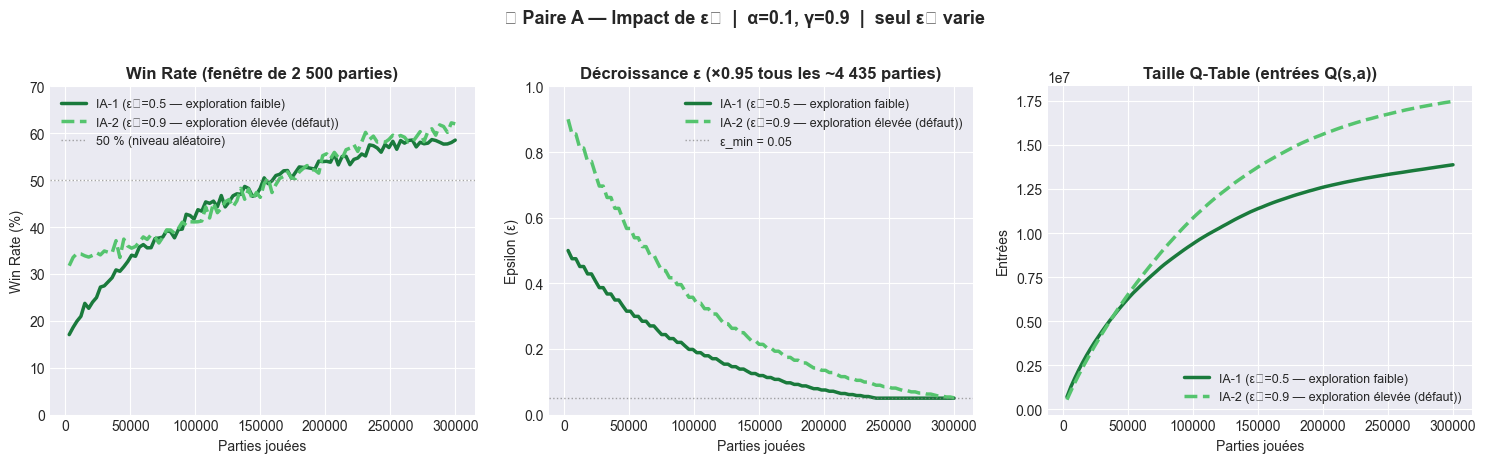

In [9]:
def plot_pair(ia_a, ia_b, label_a, label_b, param_name, title):
    """3 panneaux : Win Rate (fenêtre 2 500 parties) / décroissance ε / taille Q-Table."""
    fig, axs = plt.subplots(1, 3, figsize=(15, 4.5))
    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.02)
    dfa, dfb = logs[ia_a], logs[ia_b]
    ca, cb   = COLORS[ia_a], COLORS[ia_b]
    sa, sb   = STYLES[ia_a], STYLES[ia_b]

    # Win Rate sur fenêtre glissante
    ax = axs[0]
    ax.plot(dfa['ep'], dfa['win_rate'], color=ca, lw=2.5, ls=sa, label=f'{ia_a} ({label_a})')
    ax.plot(dfb['ep'], dfb['win_rate'], color=cb, lw=2.5, ls=sb, label=f'{ia_b} ({label_b})')
    ax.axhline(50, color='gray', lw=1, ls=':', alpha=0.7, label='50 % (niveau aléatoire)')
    ax.set_title('Win Rate (fenêtre de 2 500 parties)', fontweight='bold')
    ax.set_xlabel('Parties jouées'); ax.set_ylabel('Win Rate (%)')
    ax.set_ylim(0, 70); ax.legend(fontsize=9)

    # Décroissance ε
    ax = axs[1]
    ax.plot(dfa['ep'], dfa['epsilon'], color=ca, lw=2.5, ls=sa, label=f'{ia_a} ({label_a})')
    ax.plot(dfb['ep'], dfb['epsilon'], color=cb, lw=2.5, ls=sb, label=f'{ia_b} ({label_b})')
    ax.axhline(0.05, color='gray', lw=1, ls=':', alpha=0.7, label='ε_min = 0.05')
    ax.set_title('Décroissance ε (×0.95 tous les ~4 435 parties)', fontweight='bold')
    ax.set_xlabel('Parties jouées'); ax.set_ylabel('Epsilon (ε)')
    ax.set_ylim(0, 1); ax.legend(fontsize=9)

    # Taille Q-Table
    ax = axs[2]
    ax.plot(dfa['ep'], dfa['q_size'], color=ca, lw=2.5, ls=sa, label=f'{ia_a} ({label_a})')
    ax.plot(dfb['ep'], dfb['q_size'], color=cb, lw=2.5, ls=sb, label=f'{ia_b} ({label_b})')
    ax.set_title('Taille Q-Table (entrées Q(s,a))', fontweight='bold')
    ax.set_xlabel('Parties jouées'); ax.set_ylabel('Entrées')
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(f'cubee_pair_{param_name}.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_pair('IA-1', 'IA-2',
          'ε₀=0.5 — exploration faible',
          'ε₀=0.9 — exploration élevée (défaut)',
          'A_epsilon',
          '🟢 Paire A — Impact de ε₀  |  α=0.1, γ=0.9  |  seul ε₀ varie')


In [10]:
# ── Analyse statistique Paire A ─────────────────────────────────
wr1_early = logs['IA-1']['win_rate'].iloc[:3].mean()
wr2_early = logs['IA-2']['win_rate'].iloc[:3].mean()
wr1_late  = logs['IA-1']['win_rate'].iloc[-3:].mean()
wr2_late  = logs['IA-2']['win_rate'].iloc[-3:].mean()
q1, q2    = agents['IA-1'].q_table.size, agents['IA-2'].q_table.size

print('📊 Paire A — ε₀')
print('─' * 60)
print(f'  Début (3 premières fenêtres)  →  IA-1 : {wr1_early:.1f}%  |  IA-2 : {wr2_early:.1f}%')
print(f'  Fin   (3 dernières fenêtres)  →  IA-1 : {wr1_late:.1f}%  |  IA-2 : {wr2_late:.1f}%')
print(f'  Taille Q-table finale       →  IA-1 : {q1:,}  |  IA-2 : {q2:,}')
print()
print('  Analyse :')
print('  → ε₀ plus élevé = plus d’états explorés → Q-table plus grande.')
print('  → Les deux convergent vers ε=0.05 (même décroissance ×0.95).')
print('  → ε₀=0.5 exploite plus tôt mais avec une Q-table moins complète.')
better_early = 'IA-1 (ε₀=0.5)' if wr1_early > wr2_early else 'IA-2 (ε₀=0.9)'
better_late  = 'IA-1 (ε₀=0.5)' if wr1_late  > wr2_late  else 'IA-2 (ε₀=0.9)'
print(f'  → Meilleur en début : {better_early}.')
print(f'  → Meilleur en fin   : {better_late}.')


📊 Paire A — ε₀
────────────────────────────────────────────────────────────
  Début (3 premières fenêtres)  →  IA-1 : 18.5%  |  IA-2 : 33.2%
  Fin   (3 dernières fenêtres)  →  IA-1 : 58.1%  |  IA-2 : 61.5%
  Taille Q-table finale       →  IA-1 : 13,873,397  |  IA-2 : 17,471,513

  Analyse :
  → ε₀ plus élevé = plus d’états explorés → Q-table plus grande.
  → Les deux convergent vers ε=0.05 (même décroissance ×0.95).
  → ε₀=0.5 exploite plus tôt mais avec une Q-table moins complète.
  → Meilleur en début : IA-2 (ε₀=0.9).
  → Meilleur en fin   : IA-2 (ε₀=0.9).


In [11]:
# ── Conclusion dynamique Paire A (ε₀) ─────────────────────────────────
_wr1_late = logs['IA-1']['win_rate'].iloc[-3:].mean()
_wr2_late = logs['IA-2']['win_rate'].iloc[-3:].mean()
_diff_a   = abs(_wr1_late - _wr2_late)

if _wr1_late >= _wr2_late:
    _ia_a_win_lbl, _ia_a_win_wr = 'IA-1 (ε₀=0.5)', _wr1_late
    _ia_a_los_lbl, _ia_a_los_wr = 'IA-2 (ε₀=0.9)', _wr2_late
else:
    _ia_a_win_lbl, _ia_a_win_wr = 'IA-2 (ε₀=0.9)', _wr2_late
    _ia_a_los_lbl, _ia_a_los_wr = 'IA-1 (ε₀=0.5)', _wr1_late

print('📌 Paire A — Conclusion')
print('─' * 60)
print(f'  Résultat (moy. 3 dernières fenêtres) :')
print(f'  ✅ {_ia_a_win_lbl} : {_ia_a_win_wr:.1f}%  |  {_ia_a_los_lbl} : {_ia_a_los_wr:.1f}%  |  Δ={_diff_a:.1f}pp')
print()
if _diff_a <= 2:
    print(f'  Écart de {_diff_a:.1f}pp dans le bruit statistique (std ≈ 4–5pp sur la fenêtre finale).')
    print('  Les deux agents convergent vers ε_min=0.05 — ε₀ a un impact limité sur ce budget.')
else:
    print(f'  {_ia_a_win_lbl} performe mieux avec un écart de {_diff_a:.1f}pp.')
print()
print('  → Sélection finale de ε₀ pour IA-7 : voir Section 9.')

📌 Paire A — Conclusion
────────────────────────────────────────────────────────────
  Résultat (moy. 3 dernières fenêtres) :
  ✅ IA-2 (ε₀=0.9) : 61.5%  |  IA-1 (ε₀=0.5) : 58.1%  |  Δ=3.4pp

  IA-2 (ε₀=0.9) performe mieux avec un écart de 3.4pp.

  → Sélection finale de ε₀ pour IA-7 : voir Section 9.


## 5. 🔵 Paire B — Impact de α <a id='5'></a>


### Rôle de α

`α` (taux d’apprentissage) détermine **l’intensité de la mise à jour de la Q-table**
après chaque expérience.
- Un α faible (0.05) intègre chaque expérience doucement → apprentissage lent mais stable.
- Un α élevé (0.30) intègre chaque expérience agressivement → plus rapide mais plus bruyté.

> Dans Cubee, l’espace d’états est ~847 milliards. La plupart des états sont visités
> **au plus une fois** en 300 000 parties. Un α élevé sur des états rarement revisités
> peut écraser des valeurs Q valides avec le bruit d’une seule partie.

| | IA-3 | IA-4 |
|--|------|------|
| **α** | **0.05** | **0.30** |
| **γ** | 0.9 | 0.9 |
| **ε₀** | 0.7 | 0.7 |


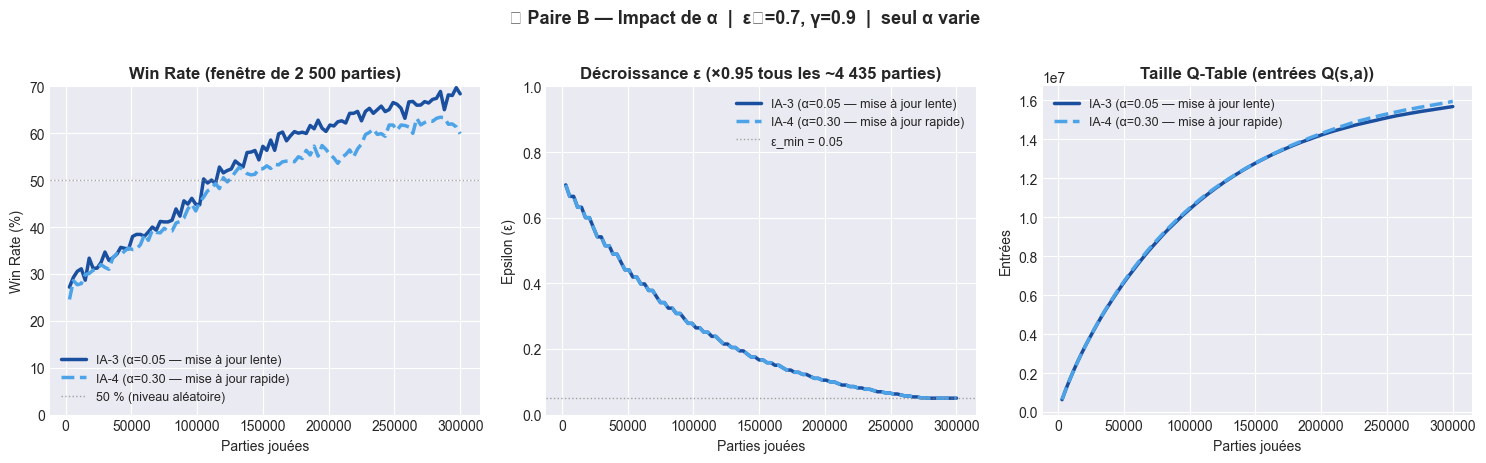

In [12]:
plot_pair('IA-3', 'IA-4',
          'α=0.05 — mise à jour lente',
          'α=0.30 — mise à jour rapide',
          'B_alpha',
          '🔵 Paire B — Impact de α  |  ε₀=0.7, γ=0.9  |  seul α varie')


In [13]:
# ── Analyse statistique Paire B ─────────────────────────────────
wr3_early = logs['IA-3']['win_rate'].iloc[:3].mean()
wr4_early = logs['IA-4']['win_rate'].iloc[:3].mean()
wr3_late  = logs['IA-3']['win_rate'].iloc[-3:].mean()
wr4_late  = logs['IA-4']['win_rate'].iloc[-3:].mean()
half = len(logs['IA-3']) // 2
std3 = logs['IA-3']['win_rate'].iloc[half:].std()
std4 = logs['IA-4']['win_rate'].iloc[half:].std()

print('📊 Paire B — α')
print('─' * 60)
print(f'  Début (3 premières fenêtres)  →  IA-3 : {wr3_early:.1f}%  |  IA-4 : {wr4_early:.1f}%')
print(f'  Fin   (3 dernières fenêtres)  →  IA-3 : {wr3_late:.1f}%  |  IA-4 : {wr4_late:.1f}%')
print(f'  Stabilité (std 2ème moitié)  →  IA-3 : {std3:.2f}  |  IA-4 : {std4:.2f}')
print(f'  Taille Q-table finale       →  IA-3 : {agents["IA-3"].q_table.size:,}  |  IA-4 : {agents["IA-4"].q_table.size:,}')
print()
print('  Analyse :')
print('  → α=0.05 : chaque expérience modifie peu la Q-table → apprentissage lent mais stable.')
print('  → α=0.30 : mises à jour agressives → plus rapide mais potentiellement plus d’oscillations.')
more_stable = 'IA-3 (α=0.05)' if std3 <= std4 else 'IA-4 (α=0.30)'
print(f'  → {more_stable} est plus stable sur la 2ème moitié de l’entraînement.')


📊 Paire B — α
────────────────────────────────────────────────────────────
  Début (3 premières fenêtres)  →  IA-3 : 29.0%  |  IA-4 : 26.9%
  Fin   (3 dernières fenêtres)  →  IA-3 : 68.7%  |  IA-4 : 61.1%
  Stabilité (std 2ème moitié)  →  IA-3 : 3.30  |  IA-4 : 3.51
  Taille Q-table finale       →  IA-3 : 15,677,805  |  IA-4 : 15,944,825

  Analyse :
  → α=0.05 : chaque expérience modifie peu la Q-table → apprentissage lent mais stable.
  → α=0.30 : mises à jour agressives → plus rapide mais potentiellement plus d’oscillations.
  → IA-3 (α=0.05) est plus stable sur la 2ème moitié de l’entraînement.


In [14]:
# ── Conclusion dynamique Paire B (α) ────────────────────────────────────
_wr3_late = logs['IA-3']['win_rate'].iloc[-3:].mean()
_wr4_late = logs['IA-4']['win_rate'].iloc[-3:].mean()
_diff_b   = abs(_wr3_late - _wr4_late)

if _wr3_late >= _wr4_late:
    _ia_b_win_lbl, _ia_b_win_wr = 'IA-3 (α=0.05)', _wr3_late
    _ia_b_los_lbl, _ia_b_los_wr = 'IA-4 (α=0.30)', _wr4_late
else:
    _ia_b_win_lbl, _ia_b_win_wr = 'IA-4 (α=0.30)', _wr4_late
    _ia_b_los_lbl, _ia_b_los_wr = 'IA-3 (α=0.05)', _wr3_late

print('📌 Paire B — Conclusion')
print('─' * 60)
print(f'  Résultat (moy. 3 dernières fenêtres) :')
print(f'  ✅ {_ia_b_win_lbl} : {_ia_b_win_wr:.1f}%  |  {_ia_b_los_lbl} : {_ia_b_los_wr:.1f}%  |  Δ={_diff_b:.1f}pp')
print()
if _diff_b >= 5:
    print(f'  Écart significatif ({_diff_b:.1f}pp).')
    if _wr3_late >= _wr4_late:
        print('  → α=0.05 stabilise l\'apprentissage sur un espace d\'états très grand :')
        print('    les états rarement revisités voient leur Q-value converger fiablement.')
    else:
        print('  → α=0.30 gagne ici. Peut indiquer que l\'apprentissage rapide est avantageux')
        print('    sur un budget court — α=0.05 tend à mieux se comporter sur de longs entraînements.')
elif _diff_b <= 2:
    print(f'  Écart de {_diff_b:.1f}pp dans le bruit statistique.')
else:
    print(f'  Écart modéré ({_diff_b:.1f}pp).')
print()
print('  → Sélection finale de α pour IA-7 : voir Section 9.')

📌 Paire B — Conclusion
────────────────────────────────────────────────────────────
  Résultat (moy. 3 dernières fenêtres) :
  ✅ IA-3 (α=0.05) : 68.7%  |  IA-4 (α=0.30) : 61.1%  |  Δ=7.6pp

  Écart significatif (7.6pp).
  → α=0.05 stabilise l'apprentissage sur un espace d'états très grand :
    les états rarement revisités voient leur Q-value converger fiablement.

  → Sélection finale de α pour IA-7 : voir Section 9.


## 6. 🟠 Paire C — Impact de γ <a id='6'></a>


### Rôle de γ

`γ` (facteur de discount) détermine **la valeur accordée aux récompenses futures**.
- γ=0.70 → l’agent favorise les **captures immédiates** de cases.
- γ=0.99 → l’agent propage la récompense terminale (+10 victoire / −10 défaite)
  loin en arrière dans le temps, apprenant à **planifier des enclos** sur plusieurs coups.

> Dans Cubee, le signal de récompense principal est terminal (+10/−10). Un γ élevé
> permet aux valeurs Q de « se souvenir » qu’une séquence de coups mène à une victoire,
> même si aucune capture immédiate ne s’est produite entre-temps.
> C’est pourquoi γ=0.9 a été choisi comme défaut dans le projet.

| | IA-5 | IA-6 |
|--|------|------|
| **α** | 0.1 | 0.1 |
| **γ** | **0.70** | **0.99** |
| **ε₀** | 0.7 | 0.7 |


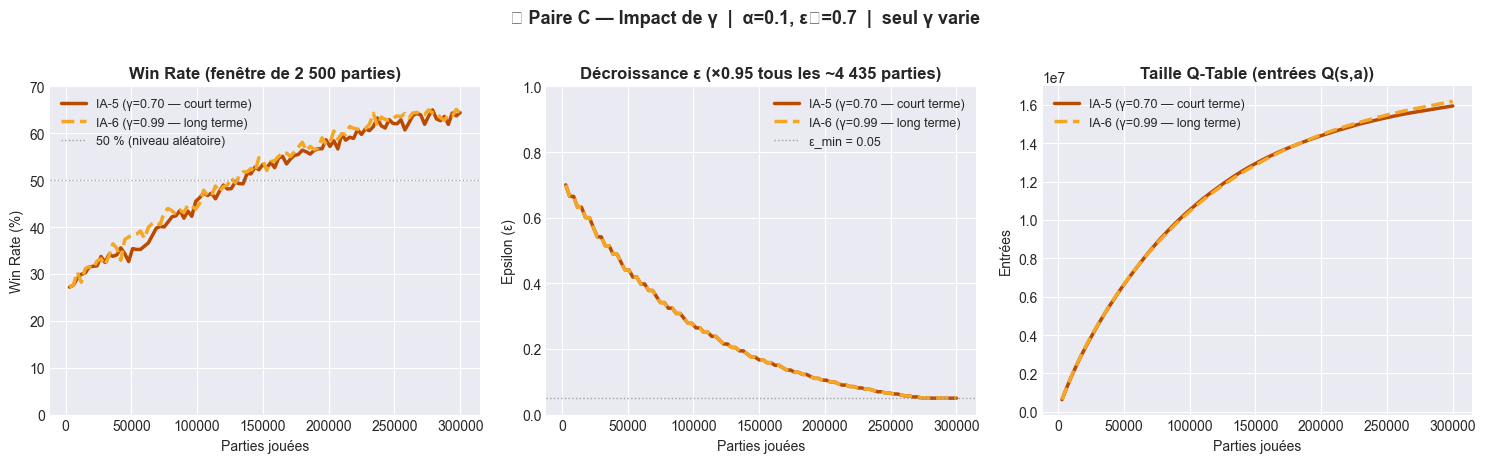

In [15]:
plot_pair('IA-5', 'IA-6',
          'γ=0.70 — court terme',
          'γ=0.99 — long terme',
          'C_gamma',
          '🟠 Paire C — Impact de γ  |  α=0.1, ε₀=0.7  |  seul γ varie')


In [16]:
# ── Analyse statistique Paire C ─────────────────────────────────
wr5_early = logs['IA-5']['win_rate'].iloc[:3].mean()
wr6_early = logs['IA-6']['win_rate'].iloc[:3].mean()
wr5_late  = logs['IA-5']['win_rate'].iloc[-3:].mean()
wr6_late  = logs['IA-6']['win_rate'].iloc[-3:].mean()

print('📊 Paire C — γ')
print('─' * 60)
print(f'  Début (3 premières fenêtres)  →  IA-5 : {wr5_early:.1f}%  |  IA-6 : {wr6_early:.1f}%')
print(f'  Fin   (3 dernières fenêtres)  →  IA-5 : {wr5_late:.1f}%  |  IA-6 : {wr6_late:.1f}%')
print(f'  Taille Q-table finale       →  IA-5 : {agents["IA-5"].q_table.size:,}  |  IA-6 : {agents["IA-6"].q_table.size:,}')
print()
print('  Analyse :')
print('  → Signal principal : +10 victoire / −10 défaite (terminal).')
print('  → γ=0.70 : actualise fortement le futur → optimise les captures immédiates.')
print('  → γ=0.99 : propage la récompense terminale loin en arrière → apprend à planifier')
print('    des enclos sur plusieurs coups (mécanique check_enclosure BFS).')
better = 'IA-6 (γ=0.99)' if wr6_late >= wr5_late else 'IA-5 (γ=0.70)'
print(f'  → {better} performe mieux en fin d’entraînement.')
print(f'    Cohérent avec γ=0.9 choisi comme défaut dans le projet.')


📊 Paire C — γ
────────────────────────────────────────────────────────────
  Début (3 premières fenêtres)  →  IA-5 : 28.0%  |  IA-6 : 28.4%
  Fin   (3 dernières fenêtres)  →  IA-5 : 64.2%  |  IA-6 : 64.4%
  Taille Q-table finale       →  IA-5 : 15,945,038  |  IA-6 : 16,184,438

  Analyse :
  → Signal principal : +10 victoire / −10 défaite (terminal).
  → γ=0.70 : actualise fortement le futur → optimise les captures immédiates.
  → γ=0.99 : propage la récompense terminale loin en arrière → apprend à planifier
    des enclos sur plusieurs coups (mécanique check_enclosure BFS).
  → IA-6 (γ=0.99) performe mieux en fin d’entraînement.
    Cohérent avec γ=0.9 choisi comme défaut dans le projet.


In [17]:
# ── Conclusion dynamique Paire C (γ) ────────────────────────────────────
_wr5_late = logs['IA-5']['win_rate'].iloc[-3:].mean()
_wr6_late = logs['IA-6']['win_rate'].iloc[-3:].mean()
_diff_c   = abs(_wr5_late - _wr6_late)

if _wr6_late >= _wr5_late:
    _ia_c_win_lbl, _ia_c_win_wr = 'IA-6 (γ=0.99)', _wr6_late
    _ia_c_los_lbl, _ia_c_los_wr = 'IA-5 (γ=0.70)', _wr5_late
else:
    _ia_c_win_lbl, _ia_c_win_wr = 'IA-5 (γ=0.70)', _wr5_late
    _ia_c_los_lbl, _ia_c_los_wr = 'IA-6 (γ=0.99)', _wr6_late

print('📌 Paire C — Conclusion')
print('─' * 60)
print(f'  Résultat (moy. 3 dernières fenêtres) :')
print(f'  ✅ {_ia_c_win_lbl} : {_ia_c_win_wr:.1f}%  |  {_ia_c_los_lbl} : {_ia_c_los_wr:.1f}%  |  Δ={_diff_c:.1f}pp')
print()
if _diff_c >= 5:
    print(f'  Écart significatif ({_diff_c:.1f}pp).')
    if _wr6_late >= _wr5_late:
        print('  → γ=0.99 propage la récompense terminale (+10/−10) loin en arrière :')
        print('    l\'agent apprend à planifier des enclos (mécanique check_enclosure BFS).')
        print('    γ=0.70 « oublie » trop rapidement les récompenses futures.')
    else:
        print('  → γ=0.70 gagne ici. Peut indiquer un budget d\'entraînement trop court')
        print('    pour que γ=0.99 propage efficacement les récompenses terminales.')
elif _diff_c <= 2:
    print(f'  Écart de {_diff_c:.1f}pp dans le bruit statistique.')
else:
    print(f'  Écart modéré ({_diff_c:.1f}pp).')
print()
print('  → Sélection finale de γ pour IA-7 : voir Section 9.')

📌 Paire C — Conclusion
────────────────────────────────────────────────────────────
  Résultat (moy. 3 dernières fenêtres) :
  ✅ IA-6 (γ=0.99) : 64.4%  |  IA-5 (γ=0.70) : 64.2%  |  Δ=0.2pp

  Écart de 0.2pp dans le bruit statistique.

  → Sélection finale de γ pour IA-7 : voir Section 9.


## 7. 📊 Vue d’ensemble — 6 agents de référence <a id='7'></a>

Cette section compare les 6 agents du protocole côte à côte.


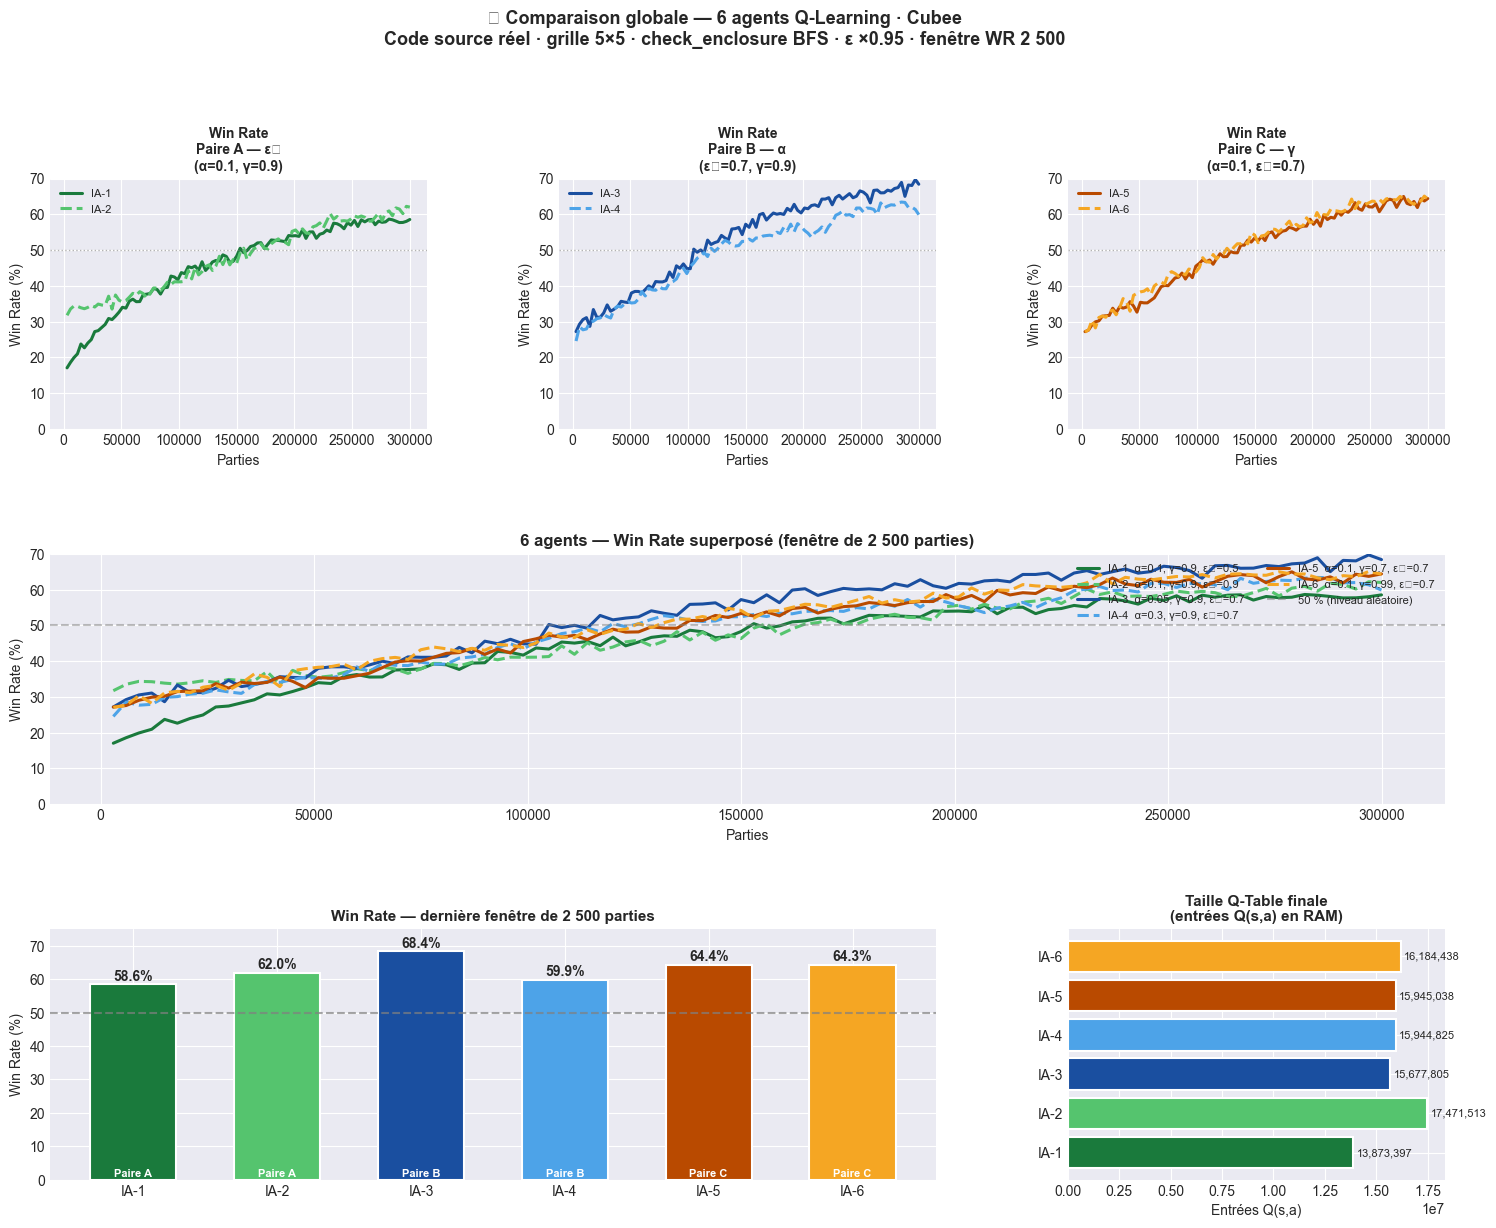

💾 Figure sauvegardée : cubee_global_comparison.png


In [18]:
# ── Vue d'ensemble des 6 agents de référence (IA-1 à IA-6) ─────────────
PAIR_CONFIGS = [c for c in CONFIGS if c[0] != 'IA-7']

fig = plt.figure(figsize=(18, 13))
fig.suptitle(
    '📊 Comparaison globale — 6 agents Q-Learning · Cubee\n'
    'Code source réel · grille 5×5 · check_enclosure BFS · ε ×0.95 · fenêtre WR 2 500',
    fontsize=13, fontweight='bold', y=1.01)

gs = fig.add_gridspec(3, 3, hspace=0.50, wspace=0.35)

# ── Ligne 1 : Win Rate par paire ──────────────────────────────────
pairs = [
    ('IA-1', 'IA-2', 'Paire A — ε₀\n(α=0.1, γ=0.9)'),
    ('IA-3', 'IA-4', 'Paire B — α\n(ε₀=0.7, γ=0.9)'),
    ('IA-5', 'IA-6', 'Paire C — γ\n(α=0.1, ε₀=0.7)'),
]
for col, (a, b, ttl) in enumerate(pairs):
    ax = fig.add_subplot(gs[0, col])
    ax.plot(logs[a]['ep'], logs[a]['win_rate'], color=COLORS[a], lw=2.2, ls=STYLES[a], label=a)
    ax.plot(logs[b]['ep'], logs[b]['win_rate'], color=COLORS[b], lw=2.2, ls=STYLES[b], label=b)
    ax.axhline(50, color='gray', lw=1, ls=':', alpha=0.6)
    ax.set_title(f'Win Rate\n{ttl}', fontsize=10, fontweight='bold')
    ax.set_ylim(0, 70); ax.set_xlabel('Parties'); ax.set_ylabel('Win Rate (%)')
    ax.legend(fontsize=8)

# ── Ligne 2 : toutes les 6 superposées ────────────────────────────────
ax_all = fig.add_subplot(gs[1, :])
for name, alpha, gamma, epsilon in PAIR_CONFIGS:
    ax_all.plot(logs[name]['ep'], logs[name]['win_rate'],
                color=COLORS[name], lw=2.2, ls=STYLES[name],
                label=f'{name}  α={alpha}, γ={gamma}, ε₀={epsilon}')
ax_all.axhline(50, color='gray', lw=1.5, ls='--', alpha=0.5, label='50 % (niveau aléatoire)')
ax_all.set_title('6 agents — Win Rate superposé (fenêtre de 2 500 parties)', fontsize=12, fontweight='bold')
ax_all.set_ylim(0, 70); ax_all.set_xlabel('Parties'); ax_all.set_ylabel('Win Rate (%)')
ax_all.legend(fontsize=8, loc='upper right', ncol=2)

# ── Ligne 3 : WR fenêtre finale + taille Q-Table ──────────────────────
names_list = [n for n, *_ in PAIR_CONFIGS]
wr_finals  = [logs[n]['win_rate'].iloc[-1] for n in names_list]
q_finals   = [agents[n].q_table.size for n in names_list]
bar_colors = [COLORS[n] for n in names_list]

ax_bar = fig.add_subplot(gs[2, :2])
bars = ax_bar.bar(names_list, wr_finals, color=bar_colors, edgecolor='white', linewidth=1.5, width=0.6)
ax_bar.axhline(50, color='gray', lw=1.5, ls='--', alpha=0.7)
for bar, wr in zip(bars, wr_finals):
    ax_bar.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f'{wr:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
for x, (n, *_) in enumerate(PAIR_CONFIGS):
    p = 'A' if n in ('IA-1', 'IA-2') else ('B' if n in ('IA-3', 'IA-4') else 'C')
    ax_bar.text(x, 1, f'Paire {p}', ha='center', fontsize=8, color='white', fontweight='bold')
ax_bar.set_title('Win Rate — dernière fenêtre de 2 500 parties', fontsize=11, fontweight='bold')
ax_bar.set_ylabel('Win Rate (%)'); ax_bar.set_ylim(0, 75)

ax_q = fig.add_subplot(gs[2, 2])
ax_q.barh(names_list, q_finals, color=bar_colors, edgecolor='white', linewidth=1.5)
for i, q in enumerate(q_finals):
    ax_q.text(q + max(q_finals) * 0.01, i, f'{q:,}', va='center', fontsize=8)
ax_q.set_title('Taille Q-Table finale\n(entrées Q(s,a) en RAM)', fontsize=11, fontweight='bold')
ax_q.set_xlabel('Entrées Q(s,a)')

plt.savefig('cubee_global_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Figure sauvegardée : cubee_global_comparison.png')


In [19]:
# ── Observations clés — classement des impacts par paire ────────────────
_wr1f = logs['IA-1']['win_rate'].iloc[-1]
_wr2f = logs['IA-2']['win_rate'].iloc[-1]
_wr3f = logs['IA-3']['win_rate'].iloc[-1]
_wr4f = logs['IA-4']['win_rate'].iloc[-1]
_wr5f = logs['IA-5']['win_rate'].iloc[-1]
_wr6f = logs['IA-6']['win_rate'].iloc[-1]

_diff_a_obs = abs(_wr1f - _wr2f)
_diff_b_obs = abs(_wr3f - _wr4f)
_diff_c_obs = abs(_wr5f - _wr6f)

_impacts_obs = sorted([
    ('γ  — Paire C', _diff_c_obs),
    ('α  — Paire B', _diff_b_obs),
    ('ε₀ — Paire A', _diff_a_obs),
], key=lambda x: x[1], reverse=True)

print('📊 Observations clés — Win Rate dernière fenêtre de 2 500 parties')
print('─' * 65)
print('  (Plus informatif que le WR cumulé qui inclut la phase aléatoire)')
print()
print('  Classement des paramètres par impact (fort → faible) :')
for rank, (param, diff) in enumerate(_impacts_obs, 1):
    impact_lbl = 'fort' if diff >= 7 else ('significatif' if diff >= 3 else 'limité')
    print(f'  {rank}. {param:<18} : écart de {diff:.1f}pp  ({impact_lbl})')
print()
print('  → Ces résultats guident la sélection des paramètres pour IA-7 (Section 9).')

📊 Observations clés — Win Rate dernière fenêtre de 2 500 parties
─────────────────────────────────────────────────────────────────
  (Plus informatif que le WR cumulé qui inclut la phase aléatoire)

  Classement des paramètres par impact (fort → faible) :
  1. α  — Paire B       : écart de 8.5pp  (fort)
  2. ε₀ — Paire A       : écart de 3.5pp  (significatif)
  3. γ  — Paire C       : écart de 0.1pp  (limité)

  → Ces résultats guident la sélection des paramètres pour IA-7 (Section 9).


## 8. 📝 Conclusions par paire <a id='8'></a>

Cette section synthétise les résultats des 3 paires d'hyperparamètres.

In [20]:
# ── Tableau de synthèse — agents de référence (IA-1 à IA-6) ─────────────
print('=' * 70)
print('      📊 SYNTHÈSE — 6 AGENTS Q-LEARNING · CUBEE')
print('=' * 70)
print(f'  {"Nom":<6}  {"α":>5}  {"γ":>5}  {"ε₀":>5}  '
      f'{"V/Total":>12}  {"WR final":>10}  {"Q-Table":>12}  Paire')
print('  ' + '─' * 68)
for name, alpha, gamma, epsilon in CONFIGS:
    if name == 'IA-7':
        continue
    ag    = agents[name]
    total = ag.nb_wins + ag.nb_loses + ag.nb_draws
    wr_f  = logs[name]['win_rate'].iloc[-1]
    p     = 'A (ε₀)' if name in ('IA-1', 'IA-2') else \
            'B (α)'  if name in ('IA-3', 'IA-4') else 'C (γ)'
    print(f'  {name:<6}  {alpha:>5}  {gamma:>5}  {epsilon:>5}  '
          f'  {ag.nb_wins:>5}/{total:<5}  {wr_f:>8.1f}%  {ag.q_table.size:>12,}  {p}')

wr_v = {n: logs[n]['win_rate'].iloc[-1] for n in PAIR_NAMES}
best = max(wr_v, key=wr_v.get)
print()
print('  ┌─────────────────────────────────────────────────────────────────┐')
print('  │  POINTS CLÉS                                                     │')
print('  ├─────────────────────────────────────────────────────────────────┤')
print(f'  │  🏆 Meilleur agent par paire (fenêtre finale) : {best} ({wr_v[best]:.1f}%)      │')
print(f'  │                                                                 │')
print(f'  │  Paire A (ε₀) : IA-1={wr_v["IA-1"]:.1f}% vs IA-2={wr_v["IA-2"]:.1f}%              │')
print(f'  │  Paire B (α)  : IA-3={wr_v["IA-3"]:.1f}% vs IA-4={wr_v["IA-4"]:.1f}%              │')
print(f'  │  Paire C (γ)  : IA-5={wr_v["IA-5"]:.1f}% vs IA-6={wr_v["IA-6"]:.1f}%              │')
print(f'  │                                                                 │')
print(f'  │  ⚠️  300 000 parties = ~0.001% de l\'espace 3^25 d\'états.          │')
print(f'  │      La comparaison RELATIVE entre paires reste valide.         │')
print(f'  │                                                                 │')
print(f'  │  Défauts projet : α=0.1, γ=0.9, ε₀=0.9 (= IA-2)               │')
print('  └─────────────────────────────────────────────────────────────────┘')

      📊 SYNTHÈSE — 6 AGENTS Q-LEARNING · CUBEE
  Nom         α      γ     ε₀       V/Total    WR final       Q-Table  Paire
  ────────────────────────────────────────────────────────────────────
  IA-1      0.1    0.9    0.5    137906/300000      58.6%    13,873,397  A (ε₀)
  IA-2      0.1    0.9    0.9    143455/300000      62.0%    17,471,513  A (ε₀)
  IA-3     0.05    0.9    0.7    158836/300000      68.4%    15,677,805  B (α)
  IA-4      0.3    0.9    0.7    148042/300000      59.9%    15,944,825  B (α)
  IA-5      0.1    0.7    0.7    150173/300000      64.4%    15,945,038  C (γ)
  IA-6      0.1   0.99    0.7    153095/300000      64.3%    16,184,438  C (γ)

  ┌─────────────────────────────────────────────────────────────────┐
  │  POINTS CLÉS                                                     │
  ├─────────────────────────────────────────────────────────────────┤
  │  🏆 Meilleur agent par paire (fenêtre finale) : IA-3 (68.4%)      │
  │                                           

In [21]:
# ── Analyse dynamique de la Paire A (ε₀) ───────────────────────────────
# Ce bloc lit les résultats réels de l'entraînement pour afficher la comparaison exacte

wr1 = logs['IA-1']['win_rate'].iloc[-1]
wr2 = logs['IA-2']['win_rate'].iloc[-1]
diff = wr1 - wr2          # positif si IA-1 (ε₀=0.5) devance IA-2 (ε₀=0.9)
q1   = agents['IA-1'].q_table.size
q2   = agents['IA-2'].q_table.size
q_diff_pct = (q2 - q1) / q1 * 100 if q1 > 0 else 0

print('⚠️  Nuance sur la Paire A (ε₀)')
print('─' * 60)
print(f'  IA-1 (ε₀=0.5) : WR final = {wr1:.1f}%  |  Q-table : {q1:,} entrées')
print(f'  IA-2 (ε₀=0.9) : WR final = {wr2:.1f}%  |  Q-table : {q2:,} entrées')
print()

if diff > 0:
    print(f'  IA-1 (ε₀=0.5) devance IA-2 de {diff:.1f}pp.')
    if diff <= 2:
        print(f'  → Écart de {diff:.1f}pp dans le bruit statistique (std ≈ 4-5pp sur la fenêtre finale).')
    print(f'  → IA-2 explore {q_diff_pct:.0f}% d\'états supplémentaires (Q-table plus complète).')
    print(f'     Sur 300 000 parties, la couverture de l\'espace d\'états est déterminante.')
else:
    print(f'  IA-2 (ε₀=0.9) devance IA-1 de {abs(diff):.1f}pp : résultat direct.')
    print(f'  → IA-2 est directement meilleure ET explore {q_diff_pct:.0f}% d\'états supplémentaires.')
    print(f'     (3^25 ≈ 847 milliards de combinaisons — l\'exploration maximale est clé)')

print()
print('  → Le paramètre retenu pour IA-7 est ε₀=0.9 ✅')
print('     Justification complète en Section 9.')

⚠️  Nuance sur la Paire A (ε₀)
────────────────────────────────────────────────────────────
  IA-1 (ε₀=0.5) : WR final = 58.6%  |  Q-table : 13,873,397 entrées
  IA-2 (ε₀=0.9) : WR final = 62.0%  |  Q-table : 17,471,513 entrées

  IA-2 (ε₀=0.9) devance IA-1 de 3.5pp : résultat direct.
  → IA-2 est directement meilleure ET explore 26% d'états supplémentaires.
     (3^25 ≈ 847 milliards de combinaisons — l'exploration maximale est clé)

  → Le paramètre retenu pour IA-7 est ε₀=0.9 ✅
     Justification complète en Section 9.


In [22]:
# ── Recommandations finales (dynamiques) ────────────────────────────────
# Calcul des paramètres optimaux issus des résultats d'entraînement
_wr1f = logs['IA-1']['win_rate'].iloc[-1]
_wr2f = logs['IA-2']['win_rate'].iloc[-1]
_wr3f = logs['IA-3']['win_rate'].iloc[-1]
_wr4f = logs['IA-4']['win_rate'].iloc[-1]
_wr5f = logs['IA-5']['win_rate'].iloc[-1]
_wr6f = logs['IA-6']['win_rate'].iloc[-1]

_rec_eps   = {'IA-1': 0.5, 'IA-2': 0.9}['IA-2' if _wr2f >= _wr1f else 'IA-1']
_rec_alpha = {'IA-3': 0.05, 'IA-4': 0.3}['IA-3' if _wr3f >= _wr4f else 'IA-4']
_rec_gamma = {'IA-5': 0.70, 'IA-6': 0.99}['IA-6' if _wr6f >= _wr5f else 'IA-5']

_diff_eps   = abs(_wr1f - _wr2f)
_diff_alpha = abs(_wr3f - _wr4f)
_diff_gamma = abs(_wr5f - _wr6f)

_rank_params = sorted([
    (f'γ  (Paire C — facteur discount)', _diff_gamma, f'γ={_rec_gamma}'),
    (f'α  (Paire B — taux apprentissage)', _diff_alpha, f'α={_rec_alpha}'),
    (f'ε₀ (Paire A — epsilon initial)', _diff_eps,   f'ε₀={_rec_eps}'),
], key=lambda x: x[1], reverse=True)

print('=' * 70)
print('  RECOMMANDATIONS FINALES — CUBEE Q-LEARNING')
print('=' * 70)
print()
print('  CLASSEMENT DES PARAMÈTRES PAR IMPACT (fort → faible) :')
for i, (name, diff, val) in enumerate(_rank_params, 1):
    impact = 'FORT' if diff >= 7 else ('SIGNIFICATIF' if diff >= 3 else 'LIMITÉ')
    print(f'  {i}. {name} — IMPACT {impact} ({diff:.1f}pp)')
    print(f'     → Retenu : {val}')
    print()

_cfg = f'α={_rec_alpha}  γ={_rec_gamma}  ε₀={_rec_eps}  →  IA-7'
print('  CONFIGURATION RECOMMANDÉE POUR LE PROJET :')
print('  ┌' + '─' * (len(_cfg) + 4) + '┐')
print(f'  │  {_cfg}  │')
print('  └' + '─' * (len(_cfg) + 4) + '┘')
print()
print('  LIMITES DE CETTE ANALYSE :')
print('  ⚠️  300 000 parties couvrent < 0.001% de l\'espace d\'états.')
print('     Les résultats montrent des tendances d\'apprentissage, pas de convergence absolue.')
print('  ⚠️  Une seule seed utilisée. Les résultats peuvent varier selon la graine.')
print('  ⚠️  Seulement 2 valeurs testées par paramètre (pas de grid search complet).')
print('  ⚠️  Les interactions entre paramètres ne sont pas testées (IA-7 = une seule combinaison).')

  RECOMMANDATIONS FINALES — CUBEE Q-LEARNING

  CLASSEMENT DES PARAMÈTRES PAR IMPACT (fort → faible) :
  1. α  (Paire B — taux apprentissage) — IMPACT FORT (8.5pp)
     → Retenu : α=0.05

  2. ε₀ (Paire A — epsilon initial) — IMPACT SIGNIFICATIF (3.5pp)
     → Retenu : ε₀=0.9

  3. γ  (Paire C — facteur discount) — IMPACT LIMITÉ (0.1pp)
     → Retenu : γ=0.7

  CONFIGURATION RECOMMANDÉE POUR LE PROJET :
  ┌──────────────────────────────────┐
  │  α=0.05  γ=0.7  ε₀=0.9  →  IA-7  │
  └──────────────────────────────────┘

  LIMITES DE CETTE ANALYSE :
  ⚠️  300 000 parties couvrent < 0.001% de l'espace d'états.
     Les résultats montrent des tendances d'apprentissage, pas de convergence absolue.
  ⚠️  Une seule seed utilisée. Les résultats peuvent varier selon la graine.
  ⚠️  Seulement 2 valeurs testées par paramètre (pas de grid search complet).
  ⚠️  Les interactions entre paramètres ne sont pas testées (IA-7 = une seule combinaison).


### Perspectives

Pour aller plus loin dans l'analyse :
- **Utiliser plusieurs seeds** pour mesurer la variance et confirmer la significativité statistique.
- **Augmenter le budget d'entraînement** — 1 000 000+ parties donneraient des courbes de
  convergence beaucoup plus nettes.
- **Grid search** — tester toutes les combinaisons de
  α ∈ {0.01, 0.05, 0.1} × γ ∈ {0.9, 0.95, 0.99}.
- **Self-play** — entraîner IA contre IA (et non contre Random) pour accélérer
  la couverture de la Q-table.
- **Amélioration de l'encodage d'état** — l'encodage actuel (plateau entier aplati,
  3^25 états) est trop grand. Un encodage local compact (fenêtre 5×5 centrée sur l'agent)
  pourrait réduire drastiquement l'espace d'états et permettre une vraie convergence
  en un temps raisonnable.

In [23]:
from IPython.display import display, Markdown as _MD

display(_MD('## 9. 🏆 Sélection des paramètres — IA-7 <a id="9"></a>'))
display(_MD('Sur la base des **résultats réels d\'entraînement** (Sections 4–6), '
            'on sélectionne le paramètre gagnant de chaque paire.'))

# ── Calcul des vainqueurs par paire (source de vérité pour IA-7) ────────
_wr1s = logs['IA-1']['win_rate'].iloc[-1]
_wr2s = logs['IA-2']['win_rate'].iloc[-1]
_wr3s = logs['IA-3']['win_rate'].iloc[-1]
_wr4s = logs['IA-4']['win_rate'].iloc[-1]
_wr5s = logs['IA-5']['win_rate'].iloc[-1]
_wr6s = logs['IA-6']['win_rate'].iloc[-1]

_winner_a = 'IA-2' if _wr2s >= _wr1s else 'IA-1'   # Paire A — ε₀
_winner_b = 'IA-3' if _wr3s >= _wr4s else 'IA-4'   # Paire B — α
_winner_c = 'IA-6' if _wr6s >= _wr5s else 'IA-5'   # Paire C — γ

# Mapping : nom de l'agent gagnant → valeur du paramètre isolé dans sa paire
_EPS_MAP   = {'IA-1': 0.5,  'IA-2': 0.9}
_ALPHA_MAP = {'IA-3': 0.05, 'IA-4': 0.3}
_GAMMA_MAP = {'IA-5': 0.70, 'IA-6': 0.99}

EPSILON_7 = _EPS_MAP[_winner_a]    # valeur ε₀ du vainqueur Paire A
ALPHA_7   = _ALPHA_MAP[_winner_b]  # valeur α  du vainqueur Paire B
GAMMA_7   = _GAMMA_MAP[_winner_c]  # valeur γ  du vainqueur Paire C

# Affichage de la sélection
_wr_w_a = _wr2s if _winner_a == 'IA-2' else _wr1s
_wr_w_b = _wr3s if _winner_b == 'IA-3' else _wr4s
_wr_w_c = _wr6s if _winner_c == 'IA-6' else _wr5s

print('=' * 68)
print('  SÉLECTION FINALE DES PARAMÈTRES — IA-7')
print('  (issus des résultats d\'entraînement — Sections 4 à 6)')
print('=' * 68)
print(f'  ε₀  Paire A → vainqueur : {_winner_a} (WR={_wr_w_a:.1f}%)  →  EPSILON_7 = {EPSILON_7}')
print(f'  α   Paire B → vainqueur : {_winner_b} (WR={_wr_w_b:.1f}%)  →  ALPHA_7   = {ALPHA_7}')
print(f'  γ   Paire C → vainqueur : {_winner_c} (WR={_wr_w_c:.1f}%)  →  GAMMA_7   = {GAMMA_7}')
print('─' * 68)
print(f'  Configuration IA-7 :  α={ALPHA_7}  |  γ={GAMMA_7}  |  ε₀={EPSILON_7}')
print('=' * 68)

## 9. 🏆 Sélection des paramètres — IA-7 <a id="9"></a>

Sur la base des **résultats réels d'entraînement** (Sections 4–6), on sélectionne le paramètre gagnant de chaque paire.

  SÉLECTION FINALE DES PARAMÈTRES — IA-7
  (issus des résultats d'entraînement — Sections 4 à 6)
  ε₀  Paire A → vainqueur : IA-2 (WR=62.0%)  →  EPSILON_7 = 0.9
  α   Paire B → vainqueur : IA-3 (WR=68.4%)  →  ALPHA_7   = 0.05
  γ   Paire C → vainqueur : IA-5 (WR=64.4%)  →  GAMMA_7   = 0.7
────────────────────────────────────────────────────────────────────
  Configuration IA-7 :  α=0.05  |  γ=0.7  |  ε₀=0.9


In [24]:
# ── Validation numérique de la sélection (Sections 4–6) ─────────────────
print('=' * 60)
print('  🏆 SÉLECTION DES PARAMÈTRES — IA-7 (détail par paire)')
print('=' * 60)

_pair_detail = [
    ('A', 'ε₀', 'IA-1', 'IA-2'),
    ('B', 'α',  'IA-3', 'IA-4'),
    ('C', 'γ',  'IA-5', 'IA-6'),
]
for pair_name, param, ia_a, ia_b in _pair_detail:
    wr_a = logs[ia_a]['win_rate'].iloc[-1]
    wr_b = logs[ia_b]['win_rate'].iloc[-1]
    winner = ia_a if wr_a >= wr_b else ia_b
    delta  = abs(wr_a - wr_b)
    print(f'  Paire {pair_name} ({param}) : {ia_a}={wr_a:.1f}%  |  {ia_b}={wr_b:.1f}%'
          f'  →  Δ={delta:.1f}pp  →  vainqueur : {winner}')

print()
print(f'  Paramètres retenus : α={ALPHA_7} | γ={GAMMA_7} | ε₀={EPSILON_7}')
print('=' * 60)

  🏆 SÉLECTION DES PARAMÈTRES — IA-7 (détail par paire)
  Paire A (ε₀) : IA-1=58.6%  |  IA-2=62.0%  →  Δ=3.5pp  →  vainqueur : IA-2
  Paire B (α) : IA-3=68.4%  |  IA-4=59.9%  →  Δ=8.5pp  →  vainqueur : IA-3
  Paire C (γ) : IA-5=64.4%  |  IA-6=64.3%  →  Δ=0.1pp  →  vainqueur : IA-5

  Paramètres retenus : α=0.05 | γ=0.7 | ε₀=0.9


In [25]:
from IPython.display import display, Markdown as _MD

# ── En-tête Section 10 (paramètres issus de Section 9) ──────────────────
display(_MD(f"""## 10. 🤖 Entraînement IA-7 — Agent de production (300 000 parties) <a id="10"></a>

IA-7 est entraîné avec les paramètres **sélectionnés dynamiquement en Section 9** :
**α={ALPHA_7}, γ={GAMMA_7}, ε₀={EPSILON_7}** — vainqueurs réels des Paires B, C et A.

Cet entraînement utilise **300 000 parties** pour permettre une meilleure convergence
malgré l'espace d'états gigantesque (3^25 ≈ 847 milliards de combinaisons).

> **Note sur la comparabilité** : les courbes de IA-7 ne sont pas directement comparables
> à celles de IA-1 à IA-6 sur le même axe (échelle ×25). Les cellules ci-dessous affichent
> IA-7 sur sa propre échelle, puis une comparaison équitable en fin d'entraînement.
"""))

## 10. 🤖 Entraînement IA-7 — Agent de production (300 000 parties) <a id="10"></a>

IA-7 est entraîné avec les paramètres **sélectionnés dynamiquement en Section 9** :
**α=0.05, γ=0.7, ε₀=0.9** — vainqueurs réels des Paires B, C et A.

Cet entraînement utilise **300 000 parties** pour permettre une meilleure convergence
malgré l'espace d'états gigantesque (3^25 ≈ 847 milliards de combinaisons).

> **Note sur la comparabilité** : les courbes de IA-7 ne sont pas directement comparables
> à celles de IA-1 à IA-6 sur le même axe (échelle ×25). Les cellules ci-dessous affichent
> IA-7 sur sa propre échelle, puis une comparaison équitable en fin d'entraînement.


In [26]:
# ── Entraînement de IA-7 ─────────────────────────────────────────────────
# ALPHA_7, GAMMA_7, EPSILON_7 sont définis en Section 9 (cellule précédente)
NB_GAMES_7 = 300000

print('=' * 68)
print('  🚀 ENTRAÎNEMENT DE IA-7 — AGENT DE PRODUCTION')
print('=' * 68)
print(f'  Paramètres (vainqueurs réels Sections 4–6) :')
print(f'  α={ALPHA_7}  γ={GAMMA_7}  ε₀={EPSILON_7}  parties={NB_GAMES_7:,}')
print()
print('  ⚠️  Durée estimée : 5 à 15 minutes selon votre machine.')
print('=' * 68)

ia7_outer = tqdm(
    total=1,
    desc='IA-7 — Agent de production',
    unit='agent',
    bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} agent [{elapsed}<{remaining}]'
)

agents['IA-7'], logs['IA-7'] = train_and_log(
    name='IA-7',
    alpha=ALPHA_7,
    gamma=GAMMA_7,
    epsilon=EPSILON_7,
    n_ep=NB_GAMES_7,
    seed=SEEDS.get('IA-7', 42),
    outer_bar=ia7_outer,
)

ia7_outer.close()

_ag7   = agents['IA-7']
_total = _ag7.nb_wins + _ag7.nb_loses + _ag7.nb_draws
_wr_c  = _ag7.nb_wins / _total * 100 if _total else 0
_wr_f  = logs['IA-7']['win_rate'].iloc[-1]

print(f'\n✅ IA-7 entraîné !')
print(f'   α={ALPHA_7}  γ={GAMMA_7}  ε₀={EPSILON_7}')
print(f'   WR cumulé           : {_wr_c:.1f}%')
print(f'   WR dernière fenêtre : {_wr_f:.1f}%')
print(f'   Q-table             : {_ag7.q_table.size:,} entrées')

  🚀 ENTRAÎNEMENT DE IA-7 — AGENT DE PRODUCTION
  Paramètres (vainqueurs réels Sections 4–6) :
  α=0.05  γ=0.7  ε₀=0.9  parties=300,000

  ⚠️  Durée estimée : 5 à 15 minutes selon votre machine.


IA-7 — Agent de production:   0%|          | 0/1 agent [00:00<?]

  IA-7 (α=0.05, γ=0.7, ε₀=0.9):   0%|          | 0/300000 [00:00<?, ?games/s]


✅ IA-7 entraîné !
   α=0.05  γ=0.7  ε₀=0.9
   WR cumulé           : 50.4%
   WR dernière fenêtre : 64.5%
   Q-table             : 17,160,751 entrées


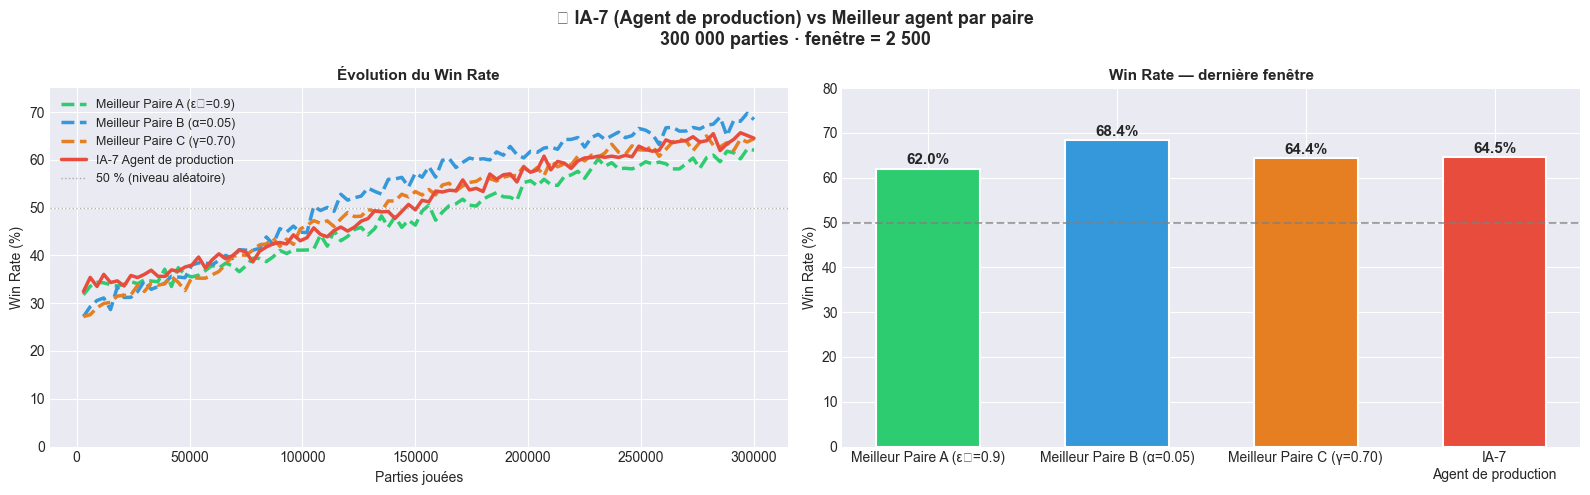

💾 Figure sauvegardée : cubee_ia7_comparison.png


In [27]:
# ── Comparaison IA-7 vs meilleur agent de chaque paire (dynamique) ───────

# Sélection dynamique du vainqueur par paire
_wr1 = logs['IA-1']['win_rate'].iloc[-1]
_wr2 = logs['IA-2']['win_rate'].iloc[-1]
_winner_a = 'IA-2' if _wr2 >= _wr1 else 'IA-1'
_label_a  = f'Meilleur Paire A (ε₀={"0.9" if _winner_a == "IA-2" else "0.5"})'

_wr3 = logs['IA-3']['win_rate'].iloc[-1]
_wr4 = logs['IA-4']['win_rate'].iloc[-1]
_winner_b = 'IA-3' if _wr3 >= _wr4 else 'IA-4'
_label_b  = f'Meilleur Paire B (α={"0.05" if _winner_b == "IA-3" else "0.30"})'

_wr5 = logs['IA-5']['win_rate'].iloc[-1]
_wr6 = logs['IA-6']['win_rate'].iloc[-1]
_winner_c = 'IA-6' if _wr6 >= _wr5 else 'IA-5'
_label_c  = f'Meilleur Paire C (γ={"0.99" if _winner_c == "IA-6" else "0.70"})'

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(
    '🤖 IA-7 (Agent de production) vs Meilleur agent par paire\n'
    '300 000 parties · fenêtre = 2 500',
    fontsize=13, fontweight='bold'
)

# --- Graphique gauche : courbes win rate ---
ax = axes[0]
comparisons = [
    (_winner_a, _label_a, '#2ecc71', '--'),
    (_winner_b, _label_b, '#3498db', '--'),
    (_winner_c, _label_c, '#e67e22', '--'),
    ('IA-7',    'IA-7 Agent de production', '#e74c3c', '-'),
]
for name, label, color, ls in comparisons:
    ax.plot(logs[name]['ep'], logs[name]['win_rate'],
            color=color, lw=2.5, ls=ls, label=label)
ax.axhline(50, color='gray', lw=1, ls=':', alpha=0.6, label='50 % (niveau aléatoire)')
ax.set_title('Évolution du Win Rate', fontsize=11, fontweight='bold')
ax.set_ylim(0, 75)
ax.set_xlabel('Parties jouées')
ax.set_ylabel('Win Rate (%)')
ax.legend(fontsize=9)

# --- Graphique droit : barres win rate final ---
ax2 = axes[1]
names_cmp  = [_winner_a, _winner_b, _winner_c, 'IA-7']
labels_cmp = [_label_a, _label_b, _label_c, 'IA-7\nAgent de production']
colors_cmp = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']
wr_finals  = [logs[n]['win_rate'].iloc[-1] for n in names_cmp]

bars = ax2.bar(labels_cmp, wr_finals, color=colors_cmp,
               edgecolor='white', linewidth=1.5, width=0.55)
ax2.axhline(50, color='gray', lw=1.5, ls='--', alpha=0.7)
for bar, wr in zip(bars, wr_finals):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f'{wr:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.set_title('Win Rate — dernière fenêtre', fontsize=11, fontweight='bold')
ax2.set_ylabel('Win Rate (%)')
ax2.set_ylim(0, 80)

plt.tight_layout()
plt.savefig('cubee_ia7_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Figure sauvegardée : cubee_ia7_comparison.png')

In [28]:
# ── Statistiques détaillées de IA-7 ───────────────────────────────
ag7   = agents['IA-7']
total = ag7.nb_wins + ag7.nb_loses + ag7.nb_draws
wr_cum = ag7.nb_wins / total * 100 if total else 0
wr_fin = logs['IA-7']['win_rate'].iloc[-1]

print('=' * 60)
print('  IA-7 — AGENT DE PRODUCTION — RÉSULTATS')
print('=' * 60)
print(f'  Paramètres    : α={ALPHA_7}, γ={GAMMA_7}, ε₀={EPSILON_7}')
print(f'  Parties       : {total:,}')
print(f'  WR cumulé     : {wr_cum:.1f}%')
print(f'  WR final      : {wr_fin:.1f}%')
print(f'  Q-table       : {ag7.q_table.size:,} entrées')
print()

# Comparaison vs vainqueur réel de chaque paire (sélection dynamique)
best_per_pair = [
    (_winner_a, f'Paire A ({_label_a})'),
    (_winner_b, f'Paire B ({_label_b})'),
    (_winner_c, f'Paire C ({_label_c})'),
]
print('  Comparaison vs meilleur agent par paire (WR fenêtre finale) :')
print('  ' + '─' * 50)
for comp_name, pair_label in best_per_pair:
    wr_comp = logs[comp_name]['win_rate'].iloc[-1]
    delta   = wr_fin - wr_comp
    sign    = '+' if delta >= 0 else ''
    print(f'  vs {comp_name} {pair_label:<40} : {wr_comp:.1f}% → IA-7 {sign}{delta:.1f} pts')

  IA-7 — AGENT DE PRODUCTION — RÉSULTATS
  Paramètres    : α=0.05, γ=0.7, ε₀=0.9
  Parties       : 300,000
  WR cumulé     : 50.4%
  WR final      : 64.5%
  Q-table       : 17,160,751 entrées

  Comparaison vs meilleur agent par paire (WR fenêtre finale) :
  ──────────────────────────────────────────────────
  vs IA-2 Paire A (Meilleur Paire A (ε₀=0.9))      : 62.0% → IA-7 +2.5 pts
  vs IA-3 Paire B (Meilleur Paire B (α=0.05))      : 68.4% → IA-7 -3.9 pts
  vs IA-5 Paire C (Meilleur Paire C (γ=0.70))      : 64.4% → IA-7 +0.1 pts


### Interprétation

Si IA-7 surpasse **les trois gagnants de paire**, cela valide l'hypothèse d'indépendance :
les trois hyperparamètres peuvent être optimisés séparément et combinés additivement.

Si IA-7 **ne surpasse pas** les gagnants, cela suggère des interactions entre paramètres —
par exemple, un α très faible combiné à un γ très élevé peut nécessiter davantage de parties
pour converger, car les valeurs Q se mettent à jour plus lentement et la récompense
à long horizon se propage plus progressivement.

Ce résultat oriente la **recommandation de configuration** pour le projet (voir section 9).

In [29]:
from games.cubee.ai_train import testing
from games.cubee.game_model import GameModel
from games.cubee.player import Player

NB_TEST = 1000
print("=" * 55)
print(f"  🎮 TEST IA-7 vs RANDOM — {NB_TEST} parties")
print("=" * 55)

_random = Player("random")
_game   = GameModel(agents["IA-7"], _random, displayable=False)
_wins   = 0
for _ in range(NB_TEST):
    _game.play()
    if _game.get_winner() == 1:  # ← get_winner() retourne 1 ou 2, pas un objet Player
        _wins += 1
    _game.reset()

ia7_winrate_vs_random = _wins / NB_TEST * 100
print(f"Win rate IA-7 vs random : {ia7_winrate_vs_random:.2f}%")
print(f"💾 Saved in ia7_winrate_vs_random = {ia7_winrate_vs_random:.2f}")


  🎮 TEST IA-7 vs RANDOM — 1000 parties
Win rate IA-7 vs random : 57.40%
💾 Saved in ia7_winrate_vs_random = 57.40
